In [1]:
!pip install imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from collections import Counter

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=5,
    n_informative=3,
    n_redundant=0,
    weights=[0.90, 0.10],
    random_state=42
)

print("Class Distribution Before SMOTE:")
print(Counter(y))

Class Distribution Before SMOTE:
Counter({np.int64(0): 447, np.int64(1): 53})


In [3]:
df = pd.DataFrame(
    X,
    columns=[
        "Feature1",
        "Feature2",
        "Feature3",
        "Feature4",
        "Feature5"
    ]
)

df["Target"] = y

df.head()

,Feature1,Feature2,Feature3,Feature4,Feature5,Target
0,-1.830633,-0.095340,-0.654076,0.724051,-0.181319,0
1,0.260281,-0.969551,-0.413465,-1.285249,-0.154301,0
2,-1.379618,-1.163654,-0.971657,1.007012,-1.140882,0
3,-0.998061,-1.511069,1.051948,-1.008788,-0.462702,0
4,-0.369610,-1.582388,0.621572,0.938263,-1.862938,0


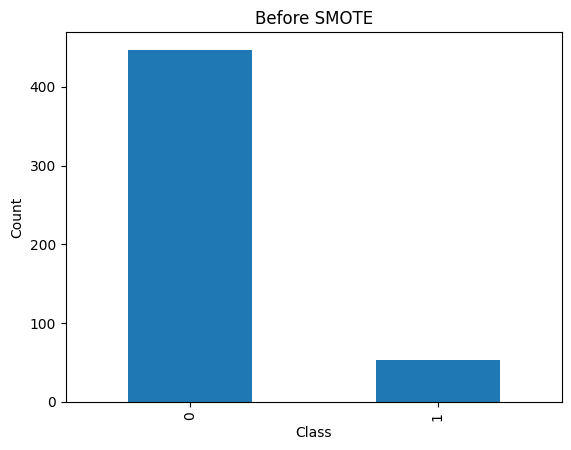

In [4]:
pd.Series(y).value_counts().plot(
    kind="bar",
    title="Before SMOTE"
)

plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [5]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("Class Distribution After SMOTE:")
print(Counter(y_resampled))

Class Distribution After SMOTE:
Counter({np.int64(0): 447, np.int64(1): 447})


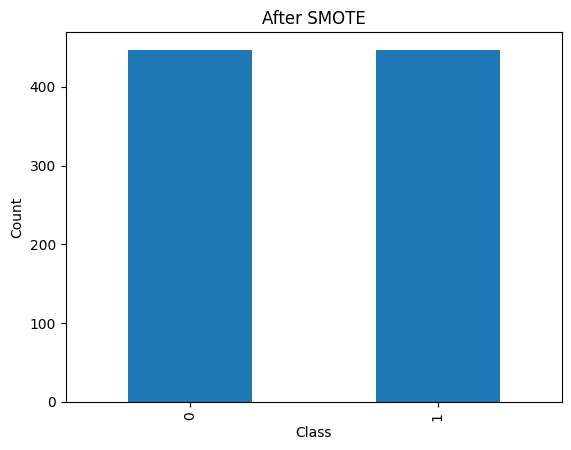

In [6]:
pd.Series(y_resampled).value_counts().plot(
    kind="bar",
    title="After SMOTE"
)

plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [7]:
balanced_df = pd.DataFrame(
    X_resampled,
    columns=[
        "Feature1",
        "Feature2",
        "Feature3",
        "Feature4",
        "Feature5"
    ]
)

balanced_df["Target"] = y_resampled

balanced_df.head()

,Feature1,Feature2,Feature3,Feature4,Feature5,Target
0,-1.830633,-0.095340,-0.654076,0.724051,-0.181319,0
1,0.260281,-0.969551,-0.413465,-1.285249,-0.154301,0
2,-1.379618,-1.163654,-0.971657,1.007012,-1.140882,0
3,-0.998061,-1.511069,1.051948,-1.008788,-0.462702,0
4,-0.369610,-1.582388,0.621572,0.938263,-1.862938,0


In [8]:
print("Original Dataset Shape :", df.shape)
print("Balanced Dataset Shape :", balanced_df.shape)

Original Dataset Shape : (500, 6)
Balanced Dataset Shape : (894, 6)


In [10]:
balanced_df.to_csv(
    "balanced_dataset_smote.csv",
    index=False
)

print("Balanced dataset saved successfully.")

Balanced dataset saved successfully.
